# Muziekclassificatie (ongesuperviseerd) — Visualisatie

**Project R.E.M. · Visualisatie-notebook**

Laadt de GMM-resultaten en visualiseert de clusterstructuur.
Geen modeltraining — alleen laden en visualiseren.

**Vereiste invoer:**
- `models/music_unsupervised/config.json`
- `models/music_unsupervised/scaler.pkl`
- `data/analysis/music_unsupervised/classified_songs_k3.csv`

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


In [2]:
# ── Configuratie ──────────────────────────────────────────────────────────────
PROJECT_ROOT = Path().resolve().parent.parent
MODELS_DIR   = PROJECT_ROOT / "models" / "music_unsupervised"
OUTPUT_DIR   = PROJECT_ROOT / "data" / "analysis" / "music_unsupervised"

# ── Visuele stijl (donker thema) ──────────────────────────────────────────────
DARK = {
    "figure.facecolor": "#0f1218",
    "axes.facecolor":   "#181e2a",
    "axes.edgecolor":   "#4a5568",
    "axes.labelcolor":  "#e2e8f0",
    "xtick.color":      "#e2e8f0",
    "ytick.color":      "#e2e8f0",
    "text.color":       "#e2e8f0",
    "grid.color":       "#2d3748",
    "grid.alpha":       0.5,
    "font.family":      "monospace",
    "legend.facecolor": "#1a2035",
    "legend.edgecolor": "#4a5568",
}
plt.rcParams.update(DARK)
plt.rcParams["figure.dpi"] = 120

OKABE_ITO = ["#56b4e9", "#e69f00", "#009e73", "#f0e442",
             "#0072b2", "#d55e00", "#cc79a7", "#999999", "#e2e8f0", "#7fcdbb"]

print(f"PROJECT_ROOT : {PROJECT_ROOT}")

PROJECT_ROOT : C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project


---
## 1. Data laden

In [3]:
# Config
config_path = MODELS_DIR / "config.json"
if not config_path.exists():
    raise FileNotFoundError(
        f"Config niet gevonden: {config_path}\n"
        "Voer eerst notebooks/ml/4_music_class_unsupervised.ipynb uit."
    )
with open(config_path, encoding="utf-8") as f:
    config = json.load(f)

optimal_k = config["optimal_k"]
features  = config["features"]
print(f"Optimaal k={optimal_k}, kenmerken: {features}")

# Geclassificeerde songs (k=3)
csv_k3 = OUTPUT_DIR / "classified_songs_k3.csv"
if not csv_k3.exists():
    raise FileNotFoundError(
        f"Geclassificeerde data niet gevonden: {csv_k3}\n"
        "Voer eerst notebooks/ml/4_music_class_unsupervised.ipynb uit."
    )
df_k3 = pd.read_csv(csv_k3)
print(f"k=3 data: {len(df_k3)} nummers")

# Geclassificeerde songs (optimaal k)
csv_opt = OUTPUT_DIR / f"classified_songs_k{optimal_k}.csv"
if not csv_opt.exists():
    raise FileNotFoundError(f"Geclassificeerde data niet gevonden: {csv_opt}")
df_opt = pd.read_csv(csv_opt)

# Scaler (voor PCA-projectie)
scaler_path = MODELS_DIR / "scaler.pkl"
if not scaler_path.exists():
    raise FileNotFoundError(f"Scaler niet gevonden: {scaler_path}")
scaler = joblib.load(scaler_path)

# BIC-sweep data
sweep = config.get("bic_sweep", {})
ks   = sorted(int(k) for k in sweep)
bics = [sweep[str(k)]["bic"]        for k in ks]
aics = [sweep[str(k)]["aic"]        for k in ks]
sils = [sweep[str(k)]["silhouette"] for k in ks]

print("Alles geladen.")

Optimaal k=10, kenmerken: ['tempo', 'energy', 'valence', 'danceability', 'acousticness', 'loudness']
k=3 data: 6198 nummers
Alles geladen.


---
## 2. BIC & silhouette — modelselectie

BIC beloont modellen die de data goed verklaren maar straft extra clusters. De laagste BIC-waarde geeft het optimale aantal clusters. De silhouette-score meet hoe goed gescheiden de clusters zijn (hoger = beter).

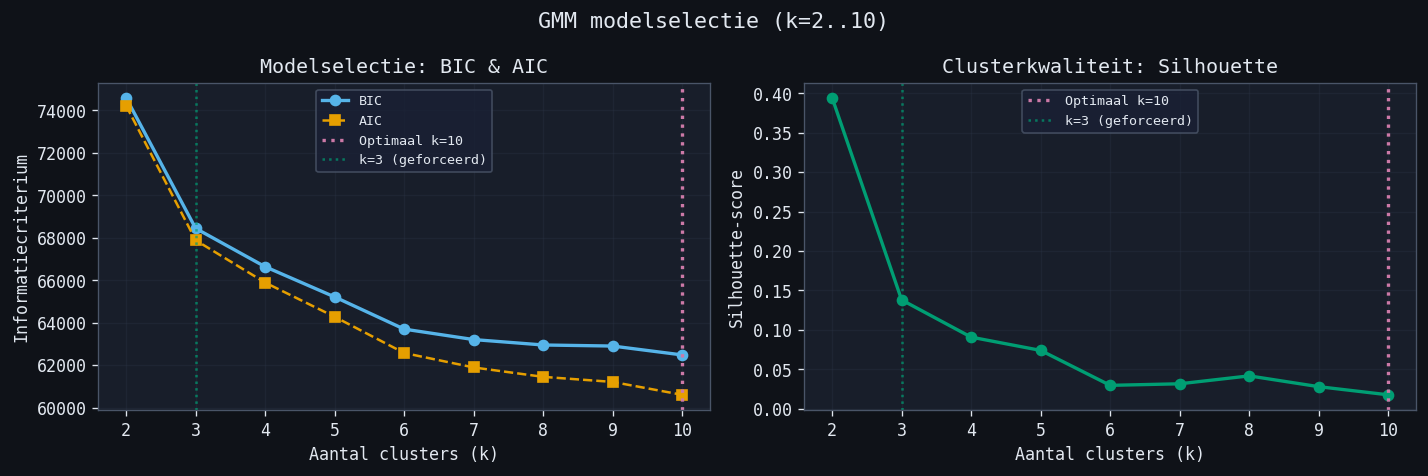

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# BIC & AIC
ax1.plot(ks, bics, "o-", color="#56b4e9", label="BIC", linewidth=2)
ax1.plot(ks, aics, "s--", color="#e69f00", label="AIC", linewidth=1.5)
ax1.axvline(optimal_k, color="#cc79a7", linestyle=":", linewidth=2,
            label=f"Optimaal k={optimal_k}")
if optimal_k != 3:
    ax1.axvline(3, color="#009e73", linestyle=":", linewidth=1.5, alpha=0.7,
                label="k=3 (geforceerd)")
ax1.set_xlabel("Aantal clusters (k)")
ax1.set_ylabel("Informatiecriterium")
ax1.set_title("Modelselectie: BIC & AIC")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Silhouette
ax2.plot(ks, sils, "o-", color="#009e73", linewidth=2)
ax2.axvline(optimal_k, color="#cc79a7", linestyle=":", linewidth=2,
            label=f"Optimaal k={optimal_k}")
if optimal_k != 3:
    ax2.axvline(3, color="#009e73", linestyle=":", linewidth=1.5, alpha=0.7,
                label="k=3 (geforceerd)")
ax2.set_xlabel("Aantal clusters (k)")
ax2.set_ylabel("Silhouette-score")
ax2.set_title("Clusterkwaliteit: Silhouette")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

fig.suptitle("GMM modelselectie (k=2..10)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. PCA-scatter — k=3 vs optimaal

PCA reduceert de zes audio-kenmerken naar twee assen zodat we de clusterstructuur kunnen visualiseren. Elk punt is één nummer, de kleur geeft het cluster aan. Goed gescheiden kleurblokken betekenen duidelijk onderscheiden muziekgroepen.

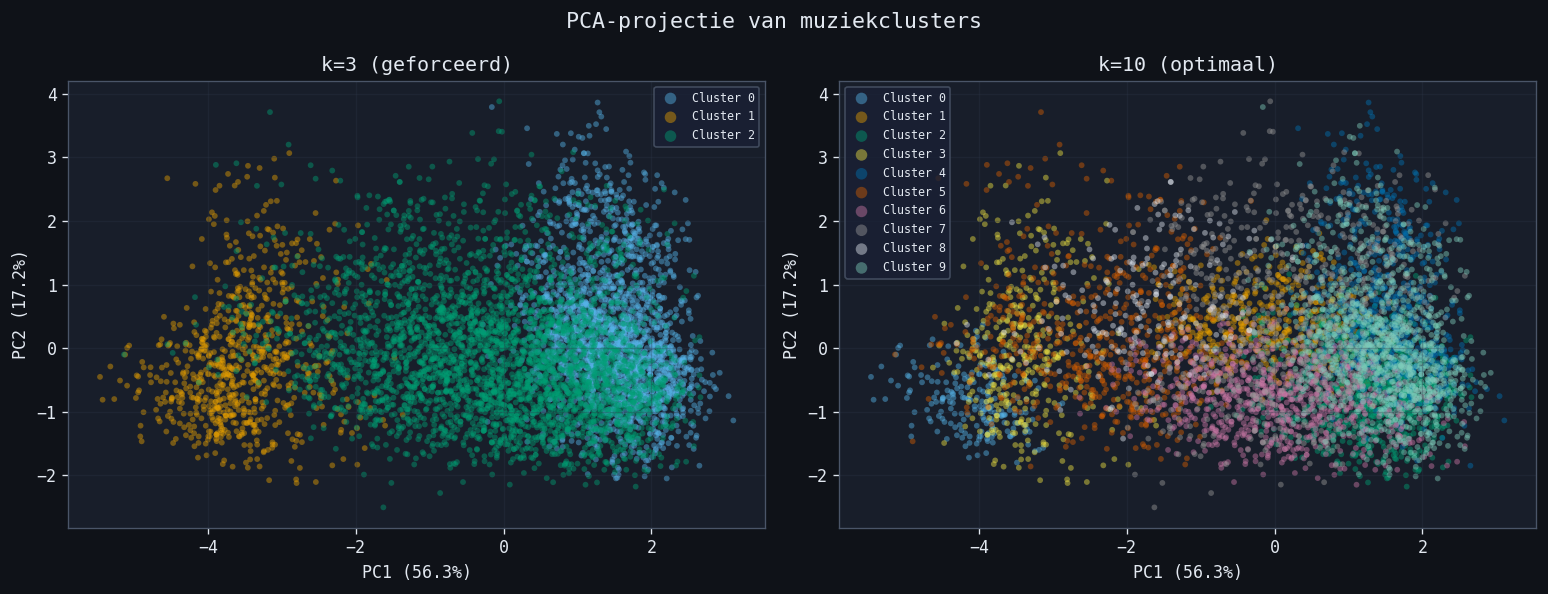

In [5]:
X = scaler.transform(df_k3[features].dropna().values)
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)
var = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (col, k, title) in zip(
    axes,
    [
        ("cluster_k3",  3,         "k=3 (geforceerd)"),
        ("cluster_opt", optimal_k, f"k={optimal_k} (optimaal)"),
    ],
):
    labels = df_k3[col].values
    for i in range(k):
        mask = labels == i
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=OKABE_ITO[i % len(OKABE_ITO)],
            label=f"Cluster {i}",
            alpha=0.45, s=12, edgecolors="none",
        )
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
    ax.legend(fontsize=7, markerscale=2)
    ax.grid(True, alpha=0.3)

fig.suptitle("PCA-projectie van muziekclusters", fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Radar chart — kenmerkprofiel per cluster (k=3)

Wat maakt elk cluster uniek? De radar toont de gemiddelde waarden per audio-kenmerk, genormaliseerd voor vergelijkbaarheid. Cluster met hoge tempo + energy = energetisch; hoge acousticness + lage energy = rustiger.

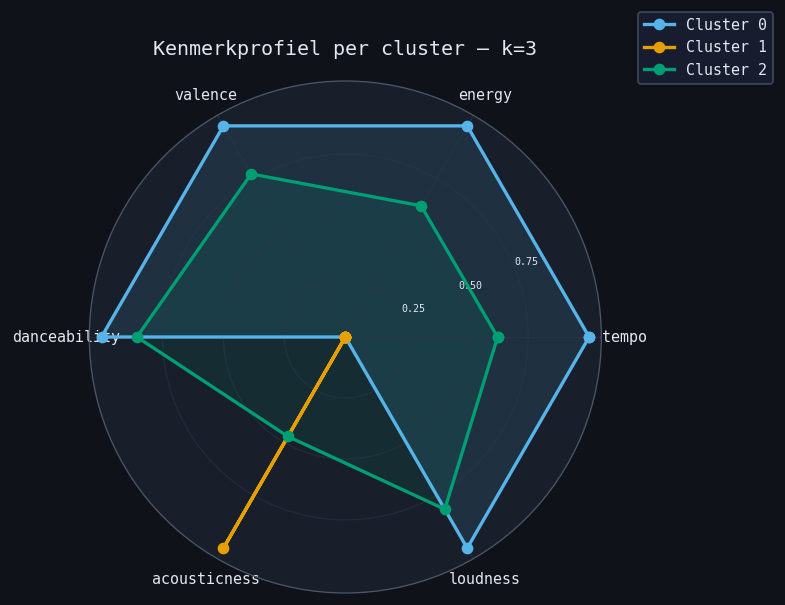

In [6]:
# Bereken gemiddelden direct vanuit de geclassificeerde data
radar_features = [f for f in features if f in df_k3.columns]
radar_data = df_k3.groupby("cluster_k3")[radar_features].mean()

# Normaliseer per kenmerk naar [0, 1]
for col in radar_data.columns:
    col_min, col_max = radar_data[col].min(), radar_data[col].max()
    if col_max > col_min:
        radar_data[col] = (radar_data[col] - col_min) / (col_max - col_min)

n_feat  = len(radar_features)
angles  = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
ax.set_facecolor("#181e2a")

for idx, (cluster_id, row) in enumerate(radar_data.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    color  = OKABE_ITO[idx % len(OKABE_ITO)]
    ax.plot(angles, values, "o-", color=color, linewidth=2,
            label=f"Cluster {cluster_id}")
    ax.fill(angles, values, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=9)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(["0.25", "0.50", "0.75"], fontsize=6, color="#4a5568")
ax.tick_params(colors="#e2e8f0")
ax.set_title("Kenmerkprofiel per cluster — k=3", pad=16)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(color="#2d3748", alpha=0.5)

plt.tight_layout()
plt.show()

---
## 5. Vergelijkingstabel — k=3 vs optimaal

Is k=3 een verdedigbare keuze? De tabel vergelijkt BIC, silhouette en clustergroottes voor beide modellen. Een lagere BIC bij optimaal k betekent dat de data meer dan drie groepen ondersteunt — maar k=3 blijft nuttig als directe vergelijking met calm/neutral/energy.

In [7]:
comparison = pd.DataFrame([
    {
        "Model":        "k=3 (geforceerd)",
        "k":            3,
        "BIC":          round(config["k3_bic"]),
        "Silhouette":   round(config["k3_silhouette"], 3),
        "BIC-verschil": 0,
    },
    {
        "Model":        f"k={optimal_k} (optimaal)",
        "k":            optimal_k,
        "BIC":          round(config["opt_bic"]),
        "Silhouette":   round(config["opt_silhouette"], 3),
        "BIC-verschil": round(config["opt_bic"] - config["k3_bic"]),
    },
])
display(comparison.set_index("Model"))

# Clustergroottes
print("\nClustergroottes k=3:")
display(df_k3["cluster_k3"].value_counts().sort_index().rename("n_songs"))

print(f"\nClustergroottes k={optimal_k}:")
display(df_opt["cluster_opt"].value_counts().sort_index().rename("n_songs"))

bic_diff = config["opt_bic"] - config["k3_bic"]
if bic_diff < -10:
    print(f"\n→ BIC-verschil = {bic_diff:.0f}: k={optimal_k} past duidelijk beter bij de data dan k=3.")
elif bic_diff > 10:
    print(f"\n→ BIC-verschil = {bic_diff:.0f}: k=3 past verrassend goed — data ondersteunt drie groepen.")
else:
    print(f"\n→ BIC-verschil = {bic_diff:.0f}: k=3 en k={optimal_k} zijn vergelijkbaar.")

,k,BIC,Silhouette,BIC-verschil
Model,,,,
k=3 (geforceerd),3,68439,0.138,0
k=10 (optimaal),10,62478,0.018,-5961



Clustergroottes k=3:


cluster_k3
0    1972
1     769
2    3457
Name: n_songs, dtype: int64


Clustergroottes k=10:


cluster_opt
0     202
1     503
2     951
3     387
4     687
5     610
6     860
7     761
8     198
9    1039
Name: n_songs, dtype: int64


→ BIC-verschil = -5961: k=10 past duidelijk beter bij de data dan k=3.
